In [1]:
import numpy as np
import pandas as pd

months_per_cycle = 132
overlap_months = 20
n_cycles = 4

cycle_strengths = [80, 120, 150, 100]

total_months = months_per_cycle * n_cycles

rows = []

for month in range(1, total_months + 1):

    for cycle in range(n_cycles):

        # Cycle start time (with overlap)
        cycle_start = cycle * months_per_cycle - overlap_months

        if month < cycle_start or month > cycle_start + months_per_cycle:
            continue

        # Phase of this cycle
        phase = (month - cycle_start) / months_per_cycle
        if phase < 0 or phase > 1:
            continue

        S_n = cycle_strengths[cycle]
        x = phase

        # Mean latitude
        lambda_n = 12.2 + 0.022 * S_n
        lambda_i = (26.4 - 34.2*x + 16.1*x**2) * (lambda_n / 14.6)

        sigma_i = (0.14 + 1.05*x - 0.78*x**2) * lambda_i

        # Sunspot number profile
        R = S_n * np.sin(np.pi * phase)**2

        # Number of symmetric BMR pairs this month
        N_pairs = int(R / 2.75 / 2)

        for s in range(N_pairs):

            lat = np.random.normal(lambda_i, sigma_i)
            lon = np.random.uniform(0, 360)

            # Area distribution (μHem)
            A = np.random.lognormal(mean=np.log(45), sigma=np.log(3))

            # Radius (Mm)
            area_m2 = A * 3.05e16
            radius_m = np.sqrt(area_m2 / np.pi)
            radius_Mm = radius_m / 1e6
            radius_Mm = radius_Mm/100

            # Magnetic flux
            flux = 7e19 * A
            flux = flux / 1e17

            # Tilt angle
            Tn = 1.73 - 0.0035 * S_n
            cycle_sign = (-1)**cycle
            tilt = cycle_sign * Tn * np.sqrt(abs(lat))

            # asymmetry strength (small)
            asym = 0.1   # 10% asymmetry

            # North
            flux_n = flux * (1 + asym * np.random.randn()*0.2)
            lat_n = lat
            tilt_n = tilt

            rows.append([month, lat_n, tilt_n, radius_Mm, lon, flux_n])

            # South (slightly different)
            flux_s = flux * (1 - asym * np.random.randn()*0.2)
            lat_s = -lat * (1 + asym * 0.05*np.random.randn())
            tilt_s = -tilt * (1 + asym * 0.1*np.random.randn())

            rows.append([month, lat_s, tilt_s, radius_Mm, lon, flux_s])


# Save file
df = pd.DataFrame(rows)
df.to_csv("BMR_4cycles_overlap_08_apr_slight_asymm.txt", sep=" ", header=False, index=False, float_format="%.6f")

print("Total months:", total_months)
print("Total BMRs:", len(df))

Total months: 528
Total BMRs: 10266


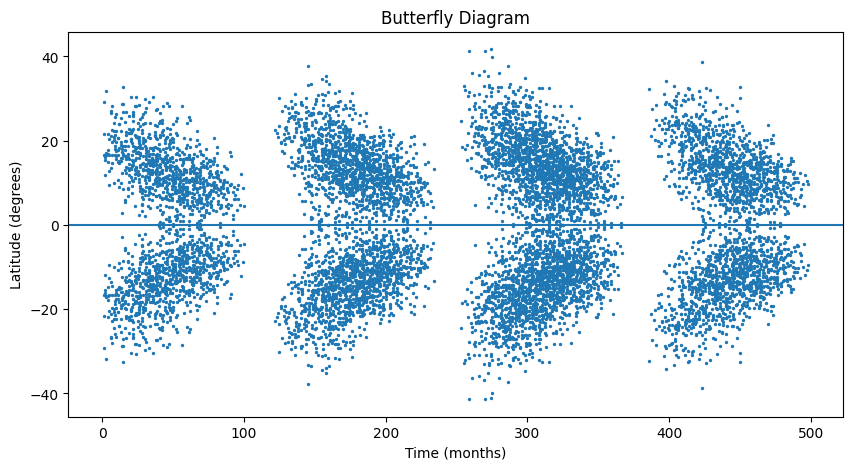

In [3]:
import matplotlib.pyplot as plt

# Load your generated file
df = pd.read_csv("BMR_4cycles_overlap_08_apr_slight_asymm.txt", sep=" ", header=None)

month = df[0]
lat = df[1]

plt.figure(figsize=(10,5))
plt.scatter(month, lat, s=2)
plt.xlabel("Time (months)")
plt.ylabel("Latitude (degrees)")
plt.title("Butterfly Diagram")
plt.axhline(0)  # equator
plt.show()